In [101]:
import joblib
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.tree import DecisionTreeClassifier
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.model_selection import GridSearchCV
from imblearn.pipeline import Pipeline as ImbPipeline
from imblearn.over_sampling import SMOTE
from sklearn.metrics import *
from sklearn import tree
 

In [102]:
df = pd.read_csv("clean_titanic.csv")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


In [103]:
df.columns

Index(['survived', 'pclass', 'sex', 'age', 'sibsp', 'parch', 'fare',
       'embarked', 'class', 'who', 'adult_male', 'embark_town', 'alive',
       'alone'],
      dtype='object')

In [104]:
df[['class','pclass']]

,class,pclass
0,Third,3
1,First,1
2,Third,3
3,First,1
4,Third,3
...,...,...
884,Second,2
885,First,1
886,Third,3
887,First,1


class is the numbered representation of pclass. They are highly correlated. so we have to remove class column.

In [105]:
df[['sex','age','who','adult_male']]

,sex,age,who,adult_male
0,male,22.0,man,True
1,female,38.0,woman,False
2,female,26.0,woman,False
3,female,35.0,woman,False
4,male,35.0,man,True
...,...,...,...,...
884,male,27.0,man,True
885,female,19.0,woman,False
886,female,28.0,woman,False
887,male,26.0,man,True


Columns like "who", "adult_male" are derived from "sex","age" so we can drop these columns

In [106]:
df[['embarked','embark_town']]

,embarked,embark_town
0,S,Southampton
1,C,Cherbourg
2,S,Southampton
3,S,Southampton
4,S,Southampton
...,...,...
884,S,Southampton
885,S,Southampton
886,S,Southampton
887,C,Cherbourg


"embark_town" is the full form of town names of "embarked" so these two are dependent columns we can remove any one of them

In [107]:
df[['sibsp', 'parch','alone']]

,sibsp,parch,alone
0,1,0,False
1,1,0,False
2,0,0,True
3,1,0,False
4,0,0,True
...,...,...,...
884,0,0,True
885,0,0,True
886,1,2,False
887,0,0,True


In [108]:
df[['survived','alive']]

,survived,alive
0,0,no
1,1,yes
2,1,yes
3,1,yes
4,0,no
...,...,...
884,0,no
885,1,yes
886,0,no
887,1,yes


"alive" is derived from the "survived" column. As this is a target variable this might cause data leakage so we need to remove this column(alive)

In [109]:
df[['sibsp', 'parch','alone']]

,sibsp,parch,alone
0,1,0,False
1,1,0,False
2,0,0,True
3,1,0,False
4,0,0,True
...,...,...,...
884,0,0,True
885,0,0,True
886,1,2,False
887,0,0,True


In [110]:
df['embarked'].value_counts()

embarked
S    644
C    168
Q     77
Name: count, dtype: int64

"alone" column is dependent on sibsp, parch so we can remove alone column

### Part B — Predictive modeling, continuing from the same cleaned data


In [111]:
X = df.drop(columns=['survived','alive','class','embark_town','adult_male','who','alone'])
y = df['survived']

y.value_counts()



survived
0    549
1    340
Name: count, dtype: int64

The target variable is not balanced, non-survived is more than survived. so stratified train-test split is used to equally distribute in both training and testing datasets.

In [112]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)


In [113]:
print("y Train\n",y_train.value_counts())
print("y Test\n",y_test.value_counts())

y Train
 survived
0    439
1    272
Name: count, dtype: int64
y Test
 survived
0    110
1     68
Name: count, dtype: int64


Before splitting, the dataset contained 549 non-survivors and 340 survivors. A stratified train-test split was used to preserve this class distribution in both the training and testing datasets. After splitting, the training set contained 439 non-survivors and 272 survivors, while the testing set contained 110 non-survivors and 68 survivors, maintaining approximately the same class proportions/ratio as the original dataset. This helps ensure that the models are trained and evaluated on representative data.

In [114]:
print("Feature Columns\n",X_train.columns)


Feature Columns
 Index(['pclass', 'sex', 'age', 'sibsp', 'parch', 'fare', 'embarked'], dtype='object')


In [115]:
num_features = ['age', 'sibsp', 'parch', 'fare']
cat_features = ['sex', 'embarked']

# Define transformers for preprocessing
num_transformer = StandardScaler()  # Standardize numerical features
cat_transformer = OneHotEncoder(drop='first',handle_unknown='ignore')  # One-hot encode categorical features

# Combine transformers into a single preprocessor
preprocessor = ColumnTransformer([
    ('num', num_transformer, num_features),
    ('cat', cat_transformer, cat_features)
])

Missing values were handled during the data cleaning stage (Part A). Therefore, no imputation step is included in the preprocessing pipeline. The preprocessing pipeline performs only feature scaling for numeric variables and one-hot encoding for categorical variables.

#### Pipeline

In [116]:
pipeline1 = Pipeline([
    ('preprocessor', preprocessor),  # Apply preprocessing steps
    ('classifier',LogisticRegression())
])
pipeline2 = Pipeline([
    ('preprocessor', preprocessor),  # Apply preprocessing steps
    ('classifier', DecisionTreeClassifier(max_depth=3,random_state=42))  
])
pipeline3 = Pipeline([
    ('preprocessor', preprocessor),  # Apply preprocessing steps
    ('classifier', RandomForestClassifier(n_estimators=100, random_state=42))  # ML model (RandomForest)
])

### Logistic Regression Model

In [117]:
pipeline1.fit(X_train,y_train)

y_pred_1 = pipeline1.predict(X_test)
print("Logistic Regression model is trained successfully")

# accuracy
logisticReg_accuracyscore = accuracy_score(y_test,y_pred_1)
print("Logistic Regression  Accuracy =",logisticReg_accuracyscore)

# precision
logisticReg_precision = precision_score(y_test,y_pred_1)
print("Logistic Regression Precision =",logisticReg_precision)

# recall
logisticReg_recall = recall_score(y_test,y_pred_1)
print("Logistic Regression Recall =",logisticReg_recall)

# f1 score
logisticReg_f1 = f1_score(y_test,y_pred_1)
print("Logistic Regression f1 =",logisticReg_f1)

# confusion matrix
lr_confussion_matrix = confusion_matrix(y_test,y_pred_1)
print("Logistic Regression Confusion Metrics\n",lr_confussion_matrix)

# roc-auc score
y_prob_1 = pipeline1.predict_proba(X_test)[:, 1]
logisticReg_roc_auc = roc_auc_score(y_test, y_prob_1)
print("Logistic Regression ROC AUC =",logisticReg_roc_auc)


plt.show()

Logistic Regression model is trained successfully
Logistic Regression  Accuracy = 0.7865168539325843
Logistic Regression Precision = 0.7586206896551724
Logistic Regression Recall = 0.6470588235294118
Logistic Regression f1 = 0.6984126984126984
Logistic Regression Confusion Metrics
 [[96 14]
 [24 44]]
Logistic Regression ROC AUC = 0.8245989304812834


### Decision Tree Model

In [118]:
pipeline2.fit(X_train,y_train)

y_pred_2 = pipeline2.predict(X_test)
print("Decision Tree model is trained successfully")

# accuracy
decisiontree_accuracyscore = accuracy_score(y_test,y_pred_2)
print("Decision Tree Accuracy =",decisiontree_accuracyscore)

# precision
decisiontree_precision = precision_score(y_test,y_pred_2)
print("Decision Tree Precision =",decisiontree_precision)

# recall
decisiontree_recall = recall_score(y_test,y_pred_2)
print("Decision Tree Recall =",decisiontree_recall)

# f1 score
decisiontree_f1 = f1_score(y_test,y_pred_2)
print("Decision Tree f1 =",decisiontree_f1)

# confusion matrix
dt_confussion_matrix = confusion_matrix(y_test,y_pred_2)
print("Decision Tree Confusion Metrics\n",dt_confussion_matrix)


# roc-auc score
y_prob_2 = pipeline2.predict_proba(X_test)[:, 1]

decisiontree_roc_auc = roc_auc_score(y_test, y_prob_2)
print("Decision Tree ROC AUC =", decisiontree_roc_auc)


plt.show()

Decision Tree model is trained successfully
Decision Tree Accuracy = 0.7865168539325843
Decision Tree Precision = 0.75
Decision Tree Recall = 0.6617647058823529
Decision Tree f1 = 0.703125
Decision Tree Confusion Metrics
 [[95 15]
 [23 45]]
Decision Tree ROC AUC = 0.821590909090909


#### Decision Tree Diagram

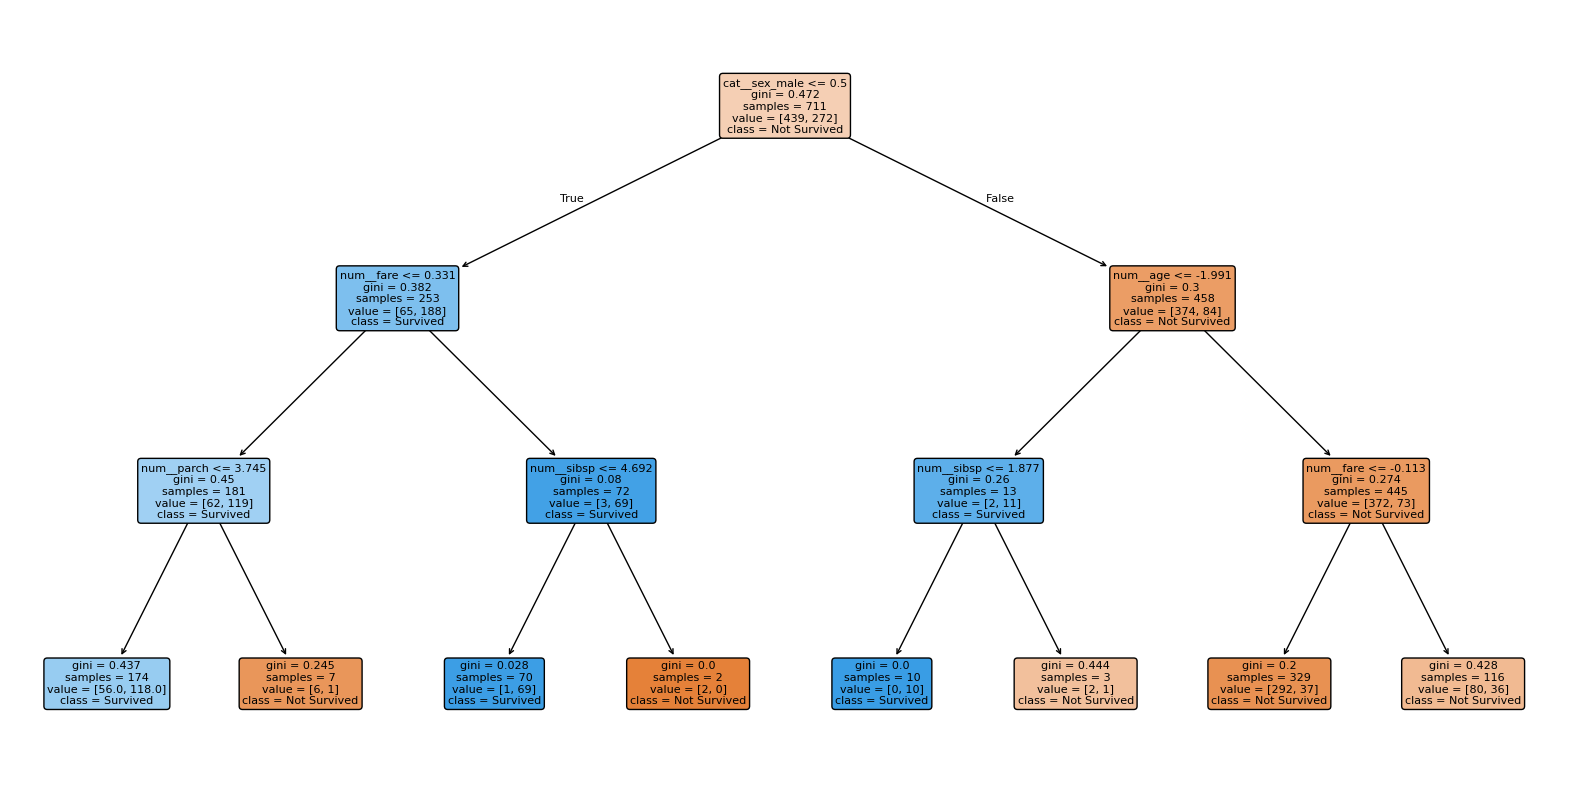

In [119]:
plt.figure(figsize=(20,10))

tree.plot_tree(
    pipeline2.named_steps["classifier"],
    feature_names=pipeline2.named_steps["preprocessor"].get_feature_names_out(),
    class_names=["Not Survived", "Survived"],
    filled=True,
    rounded=True,
    fontsize=8
)

plt.show()

### Random Forest Model

In [120]:
pipeline3.fit(X_train,y_train)

y_pred_3 = pipeline3.predict(X_test)
print("Random Forest model is trained successfully")

# accuracy
randomforest_accuracyscore = accuracy_score(y_test,y_pred_3)
print("Random Forest Accuracy =",randomforest_accuracyscore)

# precision 
randomforest_precision = precision_score(y_test,y_pred_3)
print("Random Forest Precision =",randomforest_precision)

# recall
randomforest_recall = recall_score(y_test,y_pred_3)
print("Random Forest Recall =",randomforest_recall)

# f1 score
randomforest_f1 = f1_score(y_test,y_pred_3)
print("Random Forest f1 =",randomforest_f1)

# confusion matrix
rf_confussion_matrix = confusion_matrix(y_test,y_pred_3)
print("Random Forest Confusion Metrics\n",rf_confussion_matrix)

# roc-auc score
y_prob_3 = pipeline3.predict_proba(X_test)[:, 1]
randomforest_roc_auc = roc_auc_score(y_test, y_prob_3)
print("Random Forest ROC AUC =", randomforest_roc_auc)


Random Forest model is trained successfully
Random Forest Accuracy = 0.8258426966292135
Random Forest Precision = 0.7936507936507936
Random Forest Recall = 0.7352941176470589
Random Forest f1 = 0.7633587786259542
Random Forest Confusion Metrics
 [[97 13]
 [18 50]]
Random Forest ROC AUC = 0.8295454545454546


#### Three models ROC_AUC Curve

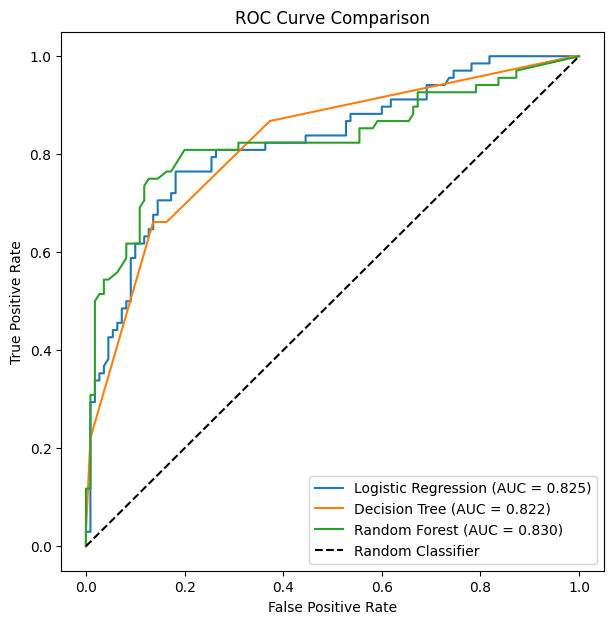

In [121]:
y_prob_1 = pipeline1.predict_proba(X_test)[:, 1]
y_prob_2 = pipeline2.predict_proba(X_test)[:, 1]
y_prob_3 = pipeline3.predict_proba(X_test)[:, 1]

# Logistic Regression
fpr1, tpr1, _ = roc_curve(y_test, y_prob_1)
auc1 = roc_auc_score(y_test, y_prob_1)

# Decision Tree
fpr2, tpr2, _ = roc_curve(y_test, y_prob_2)
auc2 = roc_auc_score(y_test, y_prob_2)

# Random Forest
fpr3, tpr3, _ = roc_curve(y_test, y_prob_3)
auc3 = roc_auc_score(y_test, y_prob_3)

plt.figure(figsize=(7, 7))

plt.plot(fpr1, tpr1, label=f"Logistic Regression (AUC = {auc1:.3f})")
plt.plot(fpr2, tpr2, label=f"Decision Tree (AUC = {auc2:.3f})")
plt.plot(fpr3, tpr3, label=f"Random Forest (AUC = {auc3:.3f})")

# Random classifier reference line
plt.plot([0, 1], [0, 1], 'k--', label="Random Classifier")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve Comparison")
plt.legend(loc="lower right")

plt.show()

#### Result Comparision Table/Dataframe

In [122]:
comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest"
    ],
    "Accuracy": [
        logisticReg_accuracyscore,
        decisiontree_accuracyscore,
        randomforest_accuracyscore
    ],
    "Precision": [
        logisticReg_precision,
        decisiontree_precision,
        randomforest_precision
    ],
    "Recall": [
        logisticReg_recall,
        decisiontree_recall,
        randomforest_recall
    ],
    "F1 Score": [
        logisticReg_f1,
        decisiontree_f1,
        randomforest_f1
    ],
    "ROC AUC": [
        logisticReg_roc_auc,
        decisiontree_roc_auc,
        randomforest_roc_auc
    ]
})

comparison_df.round(3)

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC
0,Logistic Regression,0.787,0.759,0.647,0.698,0.825
1,Decision Tree,0.787,0.750,0.662,0.703,0.822
2,Random Forest,0.826,0.794,0.735,0.763,0.830


In [123]:
y.value_counts()

survived
0    549
1    340
Name: count, dtype: int64

#### Random Forest Model with (b) class_weight='balanced'

In [124]:
pipeline_balanced = Pipeline([
    ('preprocessor', preprocessor),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        random_state=42,
        class_weight="balanced"
    ))
])

In [125]:
pipeline_balanced.fit(X_train,y_train)

y_pred_balanced = pipeline_balanced.predict(X_test)
print("Random Forest model is trained successfully")

balanced_randomforest_accuracyscore = accuracy_score(y_test,y_pred_balanced)
print("Random Forest Accuracy =",balanced_randomforest_accuracyscore)

balanced_randomforest_precision = precision_score(y_test,y_pred_balanced)
print("Random Forest Precision =",balanced_randomforest_precision)

balanced_randomforest_recall = recall_score(y_test,y_pred_balanced)
print("Random Forest Recall =",balanced_randomforest_recall)

balanced_randomforest_f1 = f1_score(y_test,y_pred_balanced)
print("Random Forest f1 =",balanced_randomforest_f1)

balanced_rf_confussion_matrix = confusion_matrix(y_test,y_pred_balanced)
print("Random Forest Confusion Metrics\n",balanced_rf_confussion_matrix)


y_prob_balanced = pipeline_balanced.predict_proba(X_test)[:, 1]
balanced_randomforest_roc_auc = roc_auc_score(y_test,y_prob_balanced)
print("Random Forest ROC AUC =", balanced_randomforest_roc_auc)


Random Forest model is trained successfully
Random Forest Accuracy = 0.8089887640449438
Random Forest Precision = 0.765625
Random Forest Recall = 0.7205882352941176
Random Forest f1 = 0.7424242424242424
Random Forest Confusion Metrics
 [[95 15]
 [19 49]]
Random Forest ROC AUC = 0.8231283422459894


#### Random Forest Model with (c) SMOTE oversampling

In [126]:
pipeline_smote = ImbPipeline([
    ('preprocessor', preprocessor),
    ('smote', SMOTE(random_state=42, sampling_strategy='minority')),
    ('classifier', RandomForestClassifier(
        n_estimators=100,
        random_state=42
    ))
])

# Train the pipeline
pipeline_smote.fit(X_train, y_train)

print("Random Forest with SMOTE trained successfully.")

y_pred_sm = pipeline_smote.predict(X_test)

smote_accuracy = accuracy_score(y_test, y_pred_sm)
smote_precision = precision_score(y_test, y_pred_sm)
smote_recall = recall_score(y_test, y_pred_sm)
smote_f1 = f1_score(y_test, y_pred_sm)

print("Accuracy :", smote_accuracy)
print("Precision:", smote_precision)
print("Recall   :", smote_recall)
print("F1 Score :", smote_f1)



Random Forest with SMOTE trained successfully.
Accuracy : 0.7865168539325843
Precision: 0.7205882352941176
Recall   : 0.7205882352941176
F1 Score : 0.7205882352941176


In [127]:
imbalance_comparison = pd.DataFrame({
    "Strategy": [
        "Baseline",
        "Class Weight",
        "SMOTE"
    ],
    "Accuracy": [
        randomforest_accuracyscore,
        balanced_randomforest_accuracyscore,
        smote_accuracy
    ],
    "Precision": [
        randomforest_precision,
        balanced_randomforest_precision,
        smote_precision
    ],
    "Recall": [
        randomforest_recall,
        balanced_randomforest_recall,
        smote_recall
    ],
    "F1 Score": [
        randomforest_f1,
        balanced_randomforest_f1,
        smote_f1
    ]
})

imbalance_comparison.round(3)

,Strategy,Accuracy,Precision,Recall,F1 Score
0,Baseline,0.826,0.794,0.735,0.763
1,Class Weight,0.809,0.766,0.721,0.742
2,SMOTE,0.787,0.721,0.721,0.721


#### Imbalance strategy comparision
The dataset showed a moderate class imbalance, with 549 non-survivors and 340 survivors. Three imbalance-handling strategies were evaluated using the Random Forest model: baseline (no handling), class_weight='balanced', and SMOTE oversampling. The baseline model achieved the best overall performance with an Accuracy of 82.6%, Precision of 79.4%, Recall of 73.5%, and F1-score of 76.3%. Both class_weight='balanced' and SMOTE resulted in lower performance, indicating that the original class imbalance was not severe enough to require additional imbalance-handling techniques. Therefore, the baseline Random Forest model was selected as the best approach for this dataset.

#### Hyperparameter Tuning

In [128]:
rf_pipeline = Pipeline([
    ('preprocessor',preprocessor),
    ('classifier',RandomForestClassifier(
        random_state=42,
        oob_score=True,
        bootstrap=True
    ))
])

param_grid = {
    "classifier__n_estimators": [50, 100, 200],
    "classifier__max_depth": [None, 5, 10, 20],
    "classifier__max_features": ["sqrt", "log2"]
}

grid_search = GridSearchCV(
    estimator=rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring='f1',
    n_jobs=-1
)

grid_search.fit(X_train, y_train)

print("Best Parameters:")
print(grid_search.best_params_)


/usr/lib/python3.10/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/usr/lib/python3.10/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/usr/lib/python3.10/multiprocessing/queues.py:122: UserWarning: pkg_resources is deprecated as an API. See https://setuptools.pypa.io/en/latest/pkg_resources.html. The pkg_resources package is slated for removal as early as 2025-11-30. Refrain from using this package or pin to Setuptools<81.
  return _ForkingPickler.loads(res)
/usr/lib/pyth

Best Parameters:
{'classifier__max_depth': 5, 'classifier__max_features': 'sqrt', 'classifier__n_estimators': 200}


In [129]:
best_model = grid_search.best_estimator_

oob_score = best_model.named_steps["classifier"].oob_score_

print("OOB Score =", oob_score)

OOB Score = 0.8157524613220816


In [130]:
df['sibsp'].value_counts()

sibsp
0    606
1    209
2     28
4     18
3     16
8      7
5      5
Name: count, dtype: int64

### Linear Regression Model on target 'fare' column

MAE = 21.09860425964044
RMSE = 41.702104679032146
R² = 0.34816257216054314
Adjusted R² = 0.3213222074848008


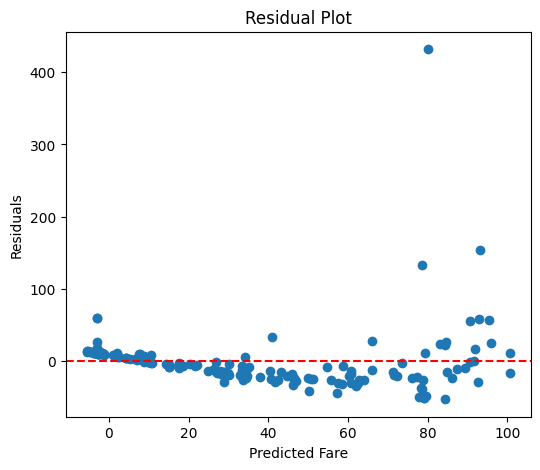

In [131]:
X_reg = df.drop(columns=['fare','alive','class','embark_town','adult_male','who','alone'])
y_reg = df['fare']

X_reg_train, X_reg_test, y_reg_train, y_reg_test = train_test_split(X_reg,y_reg,test_size=0.2,random_state=42)

linear_model = LinearRegression()

num_features = ['survived', 'pclass', 'age', 'sibsp', 'parch']
cat_features = ['sex', 'embarked']

preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_features),
    ('cat', OneHotEncoder(drop='first', handle_unknown='ignore'), cat_features)
])

linear_pipeline = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', LinearRegression())
])

linear_pipeline.fit(X_reg_train,y_reg_train)
y_pred = linear_pipeline.predict(X_reg_test)

import numpy as np

mae = mean_absolute_error(y_reg_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_reg_test, y_pred))
r2 = r2_score(y_reg_test, y_pred)

n = len(y_reg_test)
p = X_reg_train.shape[1]

adjusted_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print("MAE =", mae)
print("RMSE =", rmse)
print("R² =", r2)
print("Adjusted R² =", adjusted_r2)


residuals = y_reg_test-y_pred


plt.figure(figsize=(6,5))

plt.scatter(y_pred, residuals)

plt.axhline(y=0, color='red', linestyle='--')

plt.xlabel("Predicted Fare")
plt.ylabel("Residuals")
plt.title("Residual Plot")

plt.show()


The residual plot shows that the residuals become more spread out as the predicted fare increases. This is a sign of heteroscedasticity, meaning the model's prediction errors are not equally spread across all predicted values. The model performs better for lower fares than for higher fares.

In [132]:
final_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Decision Tree",
        "Random Forest",
        "Linear Regression"
    ],

    "Accuracy": [
        logisticReg_accuracyscore,
        decisiontree_accuracyscore,
        randomforest_accuracyscore,
        np.nan
    ],

    "Precision": [
        logisticReg_precision,
        decisiontree_precision,
        randomforest_precision,
        np.nan
    ],

    "Recall": [
        logisticReg_recall,
        decisiontree_recall,
        randomforest_recall,
        np.nan
    ],

    "F1 Score": [
        logisticReg_f1,
        decisiontree_f1,
        randomforest_f1,
        np.nan
    ],

    "ROC AUC": [
        logisticReg_roc_auc,
        decisiontree_roc_auc,
        randomforest_roc_auc,
        np.nan
    ],

    "MAE": [
        np.nan,
        np.nan,
        np.nan,
        mae
    ],

    "RMSE": [
        np.nan,
        np.nan,
        np.nan,
        rmse
    ],

    "R²": [
        np.nan,
        np.nan,
        np.nan,
        r2
    ],

    "Adjusted R²": [
        np.nan,
        np.nan,
        np.nan,
        adjusted_r2
    ]
})

final_comparison = final_comparison.round(3)
final_comparison = final_comparison.fillna("-")

final_comparison

,Model,Accuracy,Precision,Recall,F1 Score,ROC AUC,MAE,RMSE,R²,Adjusted R²
0,Logistic Regression,0.787,0.759,0.647,0.698,0.825,-,-,-,-
1,Decision Tree,0.787,0.75,0.662,0.703,0.822,-,-,-,-
2,Random Forest,0.826,0.794,0.735,0.763,0.83,-,-,-,-
3,Linear Regression,-,-,-,-,-,21.099,41.702,0.348,0.321


Among the three classification models, Random Forest is the recommended model for deployment because it achieved the best overall performance. It obtained the highest Accuracy (82.6%), Precision (79.4%), Recall (73.5%), and F1-score (76.3%), indicating the most balanced performance across all evaluation metrics. Although Logistic Regression achieved a slightly higher ROC-AUC (0.825) than Random Forest (0.823), the difference is very small, while Random Forest performed better on the other key metrics. Therefore, Random Forest is the preferred model for deployment as it provides the best overall predictive performance for classifying passenger survival.

### Save the best model

In [133]:
print("Best Parameters:", grid_search.best_params_)

best_model = grid_search.best_estimator_

joblib.dump(best_model, "best_random_forest_pipeline.pkl")

print("Pipeline saved successfully.")
loaded_pipeline = joblib.load("best_random_forest_pipeline.pkl")

print("Pipeline loaded successfully.")

sample = X_test.iloc[[0]]

prediction = loaded_pipeline.predict(sample)

print("Raw Input:")
print(sample)

print("\nActual Survival:", y_test.iloc[0])
print("Predicted Survival:", prediction[0])

Best Parameters: {'classifier__max_depth': 5, 'classifier__max_features': 'sqrt', 'classifier__n_estimators': 200}
Pipeline saved successfully.
Pipeline loaded successfully.
Raw Input:
     pclass   sex   age  sibsp  parch  fare embarked
159       3  male  44.0      0      1  16.1        S

Actual Survival: 0
Predicted Survival: 0
